# <span style="color:darkblue"> Project 2 </span>

# <span style="color:darkblue"> Zepeng Zhou </span>

# <span style="color:darkblue"> Introduction </span>

<font size = "4">

This project analyzed 186 short dramas from the Best Short Drama list on IMDb, <br>
examining their basic information to reveal audience rating trends and engagement patterns. <br>
It highlights the rapid surge of short dramas in recent years <br>
and uncovers the structural characteristics behind this phenomenon <br>
— including the dominance of certain platforms, the concentration of production companies, <br>
and the uneven distribution of content types.


<font size = "5">

Key Findings

<font size = "4">

- The overall ratings of short dramas on IMDb are relatively high, with an average of 7.48 and most clustered between 7 and 8, indicating that short dramas are generally well received by audiences.
- The distribution of review counts is highly right-skewed—most short dramas have few reviews, while a small number of popular titles attract many, showing a clear “long-tail” effect.
- The number of short dramas increased significantly starting in 2023 and exploded in 2024, reflecting the global rise of this content format.
- Platform distribution is highly uneven, with ReelShort, GoodShort, and DramaBox dominating, especially ReelShort, which holds a clear leading position in the industry.
- Although there are many production companies, production is concentrated among a few—New Leaf Publishing and ReelShort are the main producers, reflecting an “oligopolistic” structure.
- In terms of genre, romance dominate, showing that short drama creation centers on emotional storytelling, while other genres such as comedy, fantasy, and action serve as supplements.

# <span style="color:darkblue"> Install Necessary Packages and Functions </span>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# <span style="color:darkblue"> Import the Data from Project 1 </span>

In [9]:
drama_data = pd.read_csv(r"/Users/zhouzepeng/Desktop/课程/# 25 fall/DATASCI-530_Computing1 /computing_25fall/Project 1 and 2/imdb_merged_results.csv")


# <span style="color:darkblue"> Data Cleaning and Recoding </span>

<font size = "5">

Duplication check


<font size = "4">

- I double-checked the duplicate lines from before the deduplication and confirmed that they are identical.

<font size = "5">

Missing values

<font size = "4">

The following variables contain missing values: 

- rating (3; 2%)
- review count (3; 2%)
- stars (1; 1%)
- release date (2; 2%)
- country of origin (4; 2%)
- platform (32; 17%)
- production company (20; 11%)

After cross-checking with the original webpages of the respective short dramas,<br>
I found that the missing information exists because these details were not provided in the original entries.

<font size = "5">

Variable: Review count

<font size = "4">

- For the variable “number of reviews,” it is currently coded as follows:<br>
(1) If the number is below 1,000, it appears with a “–” sign in front;<br>
(2) If it exceeds 1,000, it is displayed as “(number + k).” For example, “(2.6k)” means over 2,600 reviews.<br>
I believe these extra symbols were introduced by the crawler’s parsing process rather than by the original webpage.<br>
 After comparing the scraped data with the source webpage, I confirmed that the numerical values are accurate.<br> 
 The original webpage indeed only shows values over 1,000 in the “k” format instead of providing exact counts. <br>
 I recoded this variable using regular expressions to extract only the numeric component, <br>
 and for values above 1,000, I converted them by multiplying the extracted number by 1,000.

In [ ]:
import re # Import the regular expression library

# Define a function to clean and standardize review count values
def clean_review_count(value):
    # If the value is missing (NaN), return NaN
    if pd.isna(value):
        return np.nan
    
    # Convert the value to a lowercase string and remove extra spaces
    value = str(value).lower().strip()

    # Remove any symbols except digits, dots, and 'k' (e.g., remove brackets, dashes, spaces)
    value = re.sub(r'[^0-9.k]', '', value)

    # If the value contains 'k', it means the number is in thousands (e.g., '2.6k' → 2600)
    if 'k' in value:
        try:
            return int(float(value.replace('k', '')) * 1000)
        except:
            return np.nan

    # Otherwise, extract the digits directly (e.g., '345' → 345)
    digits = re.findall(r'\d+', value)
    return int(digits[0]) if digits else np.nan


# Apply the cleaning function to the 'review_count' column and store results in a new column
drama_data['review_count_clean'] = drama_data['review_count'].apply(clean_review_count)

drama_data[['review_count', 'review_count_clean']].head(10)


,review_count,review_count_clean
0,-113,113.0
1,-149,149.0
2,-220,220.0
3,-193,193.0
4,-88,88.0
5,-172,172.0
6,-65,65.0
7,-81,81.0
8,-129,129.0
9,-58,58.0


<font size = "5">

Variable: Year

<font size = "4">

The variable “Year” contains non-numeric characters. <br>
After checking the original webpage, I found that the source data also includes such cases.<br>
For example, some entries are labeled as “2024–2025,” which I assume indicates that <br>
 the drama was released across two years. <br>
To standardize the data, I removed the hyphen, and for those spanning two years, <br>
I kept the first year to represent the initial release year of the short drama.


In [ ]:
import re  

# Define a function to clean and standardize the 'year' variable
def clean_year(value):
    # If the value is missing (NaN), return NaN
    if pd.isna(value):
        return np.nan
    
    # Convert the value to a string and remove leading/trailing spaces
    value = str(value).strip()
    
    # Extract all four-digit numbers (e.g., 2024, 2025) using a regular expression
    years = re.findall(r'\d{4}', value)
    
    # If multiple years are found (e.g., "2024–2025"), keep only the first one
    if len(years) > 0:
        return int(years[0])
    else:
        return np.nan


# Apply the cleaning function to the 'year' column and store the results in a new column
drama_data['year_clean'] = drama_data['year'].apply(clean_year)

drama_data[['year', 'year_clean']].head(10)

,year,year_clean
0,2023,2023
1,2023,2023
2,2024,2024
3,2024–2025,2024
4,2024,2024
5,2024,2024
6,2024,2024
7,2024,2024
8,2023,2023
9,2024–,2024


<font size = "5">

Variable: Platforms

<font size = "4">

I found that in the variables platform1 and platform2, aside from the missing values, <br>
there are some entries that are clearly not platform names<br>
 (for example, “link to the official site” or “Website”). <br>
 <br>
 After checking the original webpages, <br>
 I realized that the “platform” section often contains hyperlinks <br>
 rather than directly displaying the platform names.<br>
However, during the scraping process, I captured the text content of that section instead of the actual link targets.<br>

Since the sample size is relatively small, <br>
I manually corrected these cases: <br>
- I visited the webpages of the misclassified short dramas, 
- clicked on their platform links to identify the actual platforms, and updated them manually. 

If I encounter similar situations in the future, <br>
I will adjust my scraping algorithm to automatically click into those links<br>
 and extract the platform names directly from the URL.


In addition, there are some duplicate cases in the variables platform1 and platform2,<br>
 where both columns indicate the same platform. <br>
 In such cases, I kept the value in platform1 <br>
 and replaced the corresponding entry in platform2 with a missing value.

In [ ]:
# If platform1 and platform2 have the same value in a given row,
# replace the value in platform2 with NaN (missing value).
# This prevents duplicate platform information from being counted twice.
drama_data.loc[drama_data['platform1'] == drama_data['platform2'], 'platform2'] = np.nan

<font size = "5">

Variable: Production Company

<font size = "4">

Some short dramas have two or more production companies <br>
listed together in the same variable, separated by commas. <br>
To address this, I created new variables to separate them <br>

In [ ]:
# Split all production company names by commas (no limit on the number of splits)
# Example: "A Studio, B Films, C Media" → ["A Studio", "B Films", "C Media"]
company_split = drama_data['production_company'].str.split(',', expand=True)

# Automatically rename the new columns as production_company1, production_company2, ...
# The number of columns is determined by how many companies the row contains
company_split.columns = [f'production_company{i+1}' for i in range(company_split.shape[1])]

# Remove extra spaces from each cell (e.g., " A Studio " → "A Studio")
company_split = company_split.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Merge the new company columns back into the original DataFrame
drama_data = pd.concat([drama_data, company_split], axis=1)

drama_data[[col for col in drama_data.columns if 'production_company' in col]].head(10)


,production_company,production_company1,production_company2,production_company3
0,24K Onions,24K Onions,None,None
1,24K Onions,24K Onions,None,None
2,Astra Filmworks,Astra Filmworks,None,None
3,Journey Entertainment,Journey Entertainment,None,None
4,GoodShort,GoodShort,None,None
5,Tap Story,Tap Story,None,None
6,NaN,NaN,NaN,NaN
7,Big Pa Pictures,Big Pa Pictures,None,None
8,24K Onions,24K Onions,None,None
9,NaN,NaN,NaN,NaN


<font size = "4">

I also confirmed that there are no duplicate entries in the production companies.

In [ ]:
# Select all columns that start with 'production_company'
# but exclude the original combined column named 'production_company'
company_cols = [c for c in drama_data.columns 
                if c.startswith('production_company') and c != 'production_company']

# Loop through each company column (starting from the second one)
# For each pair of adjacent columns:
#   - Compare the current column with the previous one
#   - If they have the same value (duplicate company name), 
#     set the current column value to NaN to remove redundancy
for i in range(1, len(company_cols)):
    prev_col = company_cols[i - 1]
    curr_col = company_cols[i]
    drama_data.loc[drama_data[curr_col] == drama_data[prev_col], curr_col] = np.nan

drama_data[company_cols].head(10)

,production_company1,production_company2,production_company3
0,24K Onions,None,None
1,24K Onions,None,None
2,Astra Filmworks,None,None
3,Journey Entertainment,None,None
4,GoodShort,None,None
5,Tap Story,None,None
6,NaN,NaN,NaN
7,Big Pa Pictures,None,None
8,24K Onions,None,None
9,NaN,NaN,NaN


<font size = "5">

Variable: Genres

<font size = "4">

The variable Genre has already been separated for entries with more than one genre. <br>
Here, I further checked whether there are any duplicate genres <br>
within each short drama after the separation. <br>
If duplicates were found, <br>
I kept the first occurrence and replaced the later ones with missing values.

In [ ]:
# Select all columns that start with 'genre' and end with a digit (e.g., genre1, genre2, genre3)
# This excludes any other unrelated columns that might contain the word 'genre'
genre_cols = [c for c in drama_data.columns if c.startswith('genre') and c[-1].isdigit()]

# Convert each genre column to string and remove leading/trailing spaces
for c in genre_cols:
    drama_data[c] = drama_data[c].astype('string').str.strip()

# Define a function to remove duplicate genres within the same row
def dedupe_genres(row):
    seen = set() # Keep track of genres already encountered in the current row
    for c in genre_cols:
        val = row[c] # Current genre value
        key = val.lower().strip() if pd.notna(val) else val # Normalize text for comparison (ignore case and spaces)
        # If the genre is not missing:
        if pd.notna(val):
            # If it's already in the set (duplicate), replace it with NaN
            if key in seen:
                row[c] = np.nan
            # Otherwise, add it to the 'seen' set
            else:
                seen.add(key)
    return row # Return the cleaned row

# Apply the deduplication function to every row in the DataFrame
# This ensures that genre1, genre2, and genre3 in each row are unique
drama_data[genre_cols] = drama_data[genre_cols].apply(dedupe_genres, axis=1)

# <span style="color:darkblue"> Despritive Statistics  </span>


<font size = "5">

Overview of the data structure

In [ ]:
# Display a concise summary of the DataFrame, including:
# - The total number of entries (rows)
# - The column names and their data types
# - The number of non-null (non-missing) values per column
# - The memory usage of the dataset
drama_data.info()

# Generate descriptive statistics for all columns in the DataFrame
# include='all' ensures both numerical and categorical variables are summarized:
# - For numerical columns: count, mean, std, min, quartiles, max
# - For categorical columns: count, unique values, most frequent value, and its frequency
drama_data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               186 non-null    object 
 1   year                186 non-null    object 
 2   rating              183 non-null    float64
 3   review_count        183 non-null    object 
 4   stars               185 non-null    object 
 5   detail_url          186 non-null    object 
 6   storyline           186 non-null    object 
 7   genre1              186 non-null    object 
 8   genre2              62 non-null     object 
 9   genre3              24 non-null     object 
 10  release_date        184 non-null    object 
 11  country_of_origin   182 non-null    object 
 12  platform1           154 non-null    object 
 13  platform2           35 non-null     object 
 14  platform3           0 non-null      float64
 15  production_company  166 non-null    object 
 16  year_cle

,title,year,rating,review_count,stars,detail_url,storyline,genre1,genre2,genre3,release_date,country_of_origin,platform1,platform2,platform3,production_company,year_clean,review_count_clean
count,186,186,183.000000,183,185,186,186,186,62,24,184,182,154,35,0.0,166,186.000000,183.000000
unique,186,9,NaN,128,185,186,169,12,9,5,162,9,33,12,NaN,70,NaN,NaN
top,Perfect Love,2024,NaN,-44,"James Liddell, Clara Carlo, Ansley Hutchinson",https://www.imdb.com/title/tt30429530/,Add a plot in your language,Drama,Romance,Romance,"January 10, 2024 (United States)",United States,ReelShort,ReelShort,NaN,New Leaf Publishing I,NaN,NaN
freq,1,131,NaN,5,1,1,18,70,28,13,4,167,73,16,NaN,38,NaN,NaN
mean,NaN,NaN,7.480328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.607527,194.786885
std,NaN,NaN,0.767503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.981861,505.140317
min,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,6.000000
25%,NaN,NaN,7.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,49.000000
50%,NaN,NaN,7.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,85.000000
75%,NaN,NaN,7.950000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,149.000000


<font size = "5">

Rating and Review Count

<font size = "4">

First, I examined the distribution of two key numerical variables in the dataset: <br>
Rating and Review Count. 

- Rating<br>
From the overview results above, we can see that the average rating is 7.48.<br>
Based on the distribution below, the ratings show a slightly right-skewed pattern,<br>
 with most short dramas receiving relatively high scores between 7 and 8. <br>
 This indicates that short dramas on IMDb generally have higher ratings, <br>
 with mainstream works widely appreciated by audiences. <br>
 The concentration of ratings within the 7–8 range suggests that <br>
 the overall quality of short dramas on the platform is relatively high,<br>
 while it may also reflect a selection bias in user rating behavior.<br>

- Review Count<br>
From the overview results above, we can see that the average review count is 195.<br>
From the figure below, the distribution of Review Count shows a highly right-skewed pattern.<br>
The vast majority of short dramas have between 0 and 500 reviews, <br>
while only a very small number exceed 1,000, with some reaching 6,000.<br>
This long-tail distribution indicates a highly uneven pattern of audience engagement.<br>
This suggests that most short dramas receive relatively few audience reviews, <br>
while only a handful of popular titles attract exceptionally high levels of attention.<br>
A small number of top-performing dramas capture the majority of traffic and reviews, <br>
whereas medium- and small-scale productions generally experience limited audience participation.



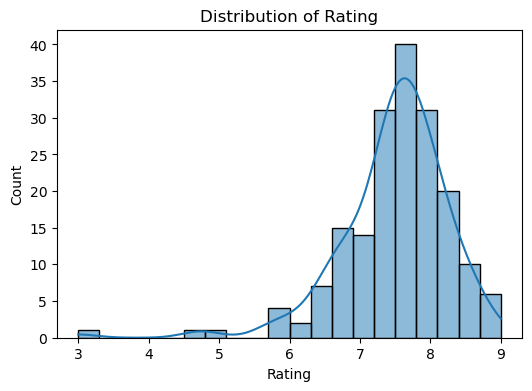

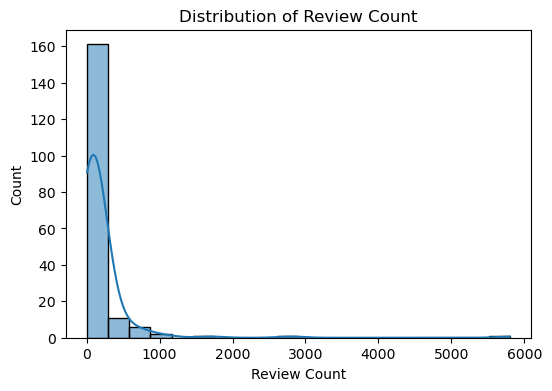

In [ ]:
# Define the numerical columns to analyze
num_cols = ['rating', 'review_count_clean']

# Generate descriptive statistics (count, mean, std, min, quartiles, max)
# for the selected numerical variables
drama_data[num_cols].describe()

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each numerical column to visualize its distribution
for col in num_cols:
    plt.figure(figsize=(6,4)) # Set figure size for clarity
    # Plot a histogram with a Kernel Density Estimate (KDE) curve
    sns.histplot(drama_data[col], kde=True, bins=20)
    
    if col == 'review_count_clean':
        plt.xlabel('Review Count')
        plt.title('Distribution of Review Count')
    elif col == 'rating':
        plt.xlabel('Rating')
        plt.title('Distribution of Rating')
    
    plt.show()


<font size = "5">

Year

<font size = "4">

Between 2018 and 2020, the number of short dramas was very limited and almost negligible.<br>
 In 2023, the number began to rise significantly, indicating that this type of content <br>
 was gradually gaining attention on the platform. <br>
 By 2024, the number of short dramas experienced explosive growth, far exceeding that <br>
 of previous years and becoming the most represented year in the sample. <br>
 This aligns with my own observations that short dramas began to <br>
 gain popularity and achieve global breakout success in 2024.

In [ ]:
# Present the counts of short dramas for each year
drama_data['year_clean'].value_counts().sort_index()

year_clean
2018      1
2019      4
2020      2
2023     39
2024    140
Name: count, dtype: int64

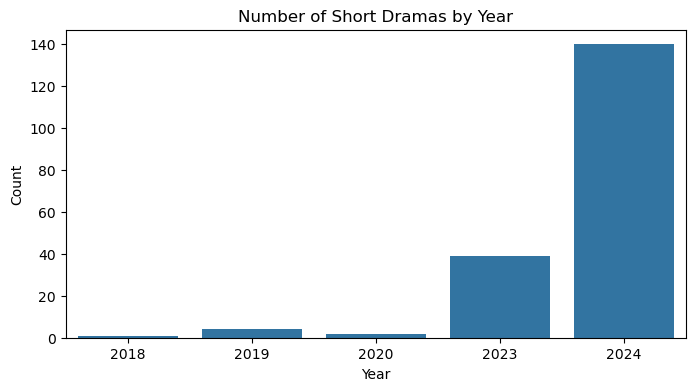

In [ ]:
# Visualization
plt.figure(figsize=(8,4))
sns.countplot(data=drama_data, x='year_clean', order=sorted(drama_data['year_clean'].dropna().unique()))
plt.title("Number of Short Dramas by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

<font size = "5">

Platforms

<font size = "4">

In total, there are 25 platforms.

From the following figure, it is evident that <br>
the distribution of short drama publishing platforms is highly uneven.<br>
ReelShort, GoodShort, and DramaBox are the dominant platforms, <br>
with ReelShort hosting the largest number of short dramas, <br>
far exceeding all others—indicating its leading position in the short drama market.<br>
Other platforms, such as GoodReels and ShortMax, have relatively few titles,<br>
 showing a clear “head concentration and long-tail dispersion” pattern.

In [ ]:
# Step 1: Combine platform1 and platform2 columns into a single Series (stack vertically)
# This allows counting all platforms together, regardless of which column they originally appeared in
platform_all = pd.concat([
    drama_data['platform1'], 
    drama_data['platform2']
], ignore_index=True)

# Step 2: Remove missing values (NaN) to avoid counting empty entries
platform_all = platform_all.dropna()

# Step 3: Count how many short dramas are published on each platform
# value_counts() returns a frequency table, sorted by count in descending order
platform_counts = platform_all.value_counts()

# Step 4: Display the top few results to check the most common platforms
print(platform_counts.head())

ReelShort    77
GoodShort    31
DramaBox     24
GoodReels     5
ShortMax      3
Name: count, dtype: int64


In [ ]:
# Calculate the total number of unique platforms across both columns
num_unique_platform = platform_all.nunique()
print(f"In total, there are {num_unique_platform} platforms.")

In total, there are 25 platforms.


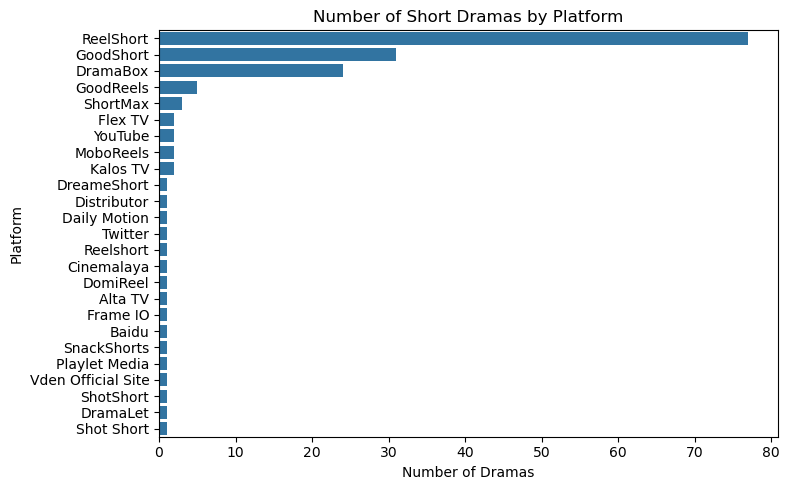

In [ ]:
# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    y=platform_counts.index, 
    x=platform_counts.values, 
    order=platform_counts.index  
)
plt.title("Number of Short Dramas by Platform")
plt.xlabel("Number of Dramas")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

<font size = "5">

Production Companies 

<font size = "4">

In total, there are 69 production companies.

From the figure below, it is evident that the distribution of <br>
short drama production companies is highly concentrated.<br>
New Leaf Publishing and ReelShort are the leading producers, <br>
with significantly more works than other companies, <br>
indicating their dominant position in short drama production.<br>
Other companies, such as 24K Onions, Drama Box, and GoodShort, <br>
have produced relatively few titles, <br>
showing a clear pattern of “head concentration and long-tail dispersion.”

In [ ]:
# Step 1. Combine three production company columns into a single Series (stack them vertically)
# This allows counting all production companies together, no matter which column they originally came from
company_all = pd.concat([
    drama_data['production_company1'],
    drama_data['production_company2'],
    drama_data['production_company3']
], ignore_index=True)

# Step 2. Remove missing values and extra spaces
# dropna() removes empty cells, and str.strip() cleans whitespace from company names
company_all = company_all.dropna().str.strip()

# Step 3. Count how many times each production company appears in the dataset
# value_counts() returns a frequency table sorted in descending order
company_counts = company_all.value_counts()

print(company_counts.head())

New Leaf Publishing I    50
ReelShort                35
24K Onions               10
Drama Box                10
GoodShort                 5
Name: count, dtype: int64


In [ ]:
# Calculate the total number of unique production companies
num_unique_companies = company_all.nunique()
print(f"In total, there are {num_unique_companies} production companies.")

In total, there are 69 production companies.


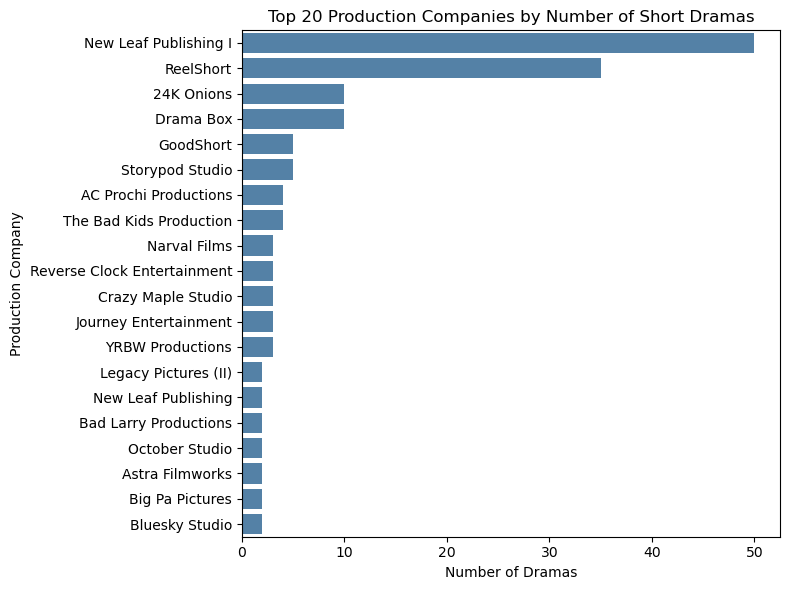

In [ ]:
# Visualization
top_n = 20
plt.figure(figsize=(8,6))
sns.barplot(
    y=company_counts.index[:top_n],
    x=company_counts.values[:top_n],
    color="steelblue"
)
plt.title(f"Top {top_n} Production Companies by Number of Short Dramas")
plt.xlabel("Number of Dramas")
plt.ylabel("Production Company")
plt.tight_layout()
plt.show()

<font size = "5">

Genres

<font size = "4">

In total, there are 15 short drama genre labels.

From the following figure, it is evident that the distribution of <br>
short drama genres shows a clear bias.<br>
Romance and Drama are the dominant genres, far exceeding others in number,<br>
 reflecting audiences’ strong preference for emotionally driven narratives.<br>
Other genres such as Comedy, Fantasy, and Action appear less frequently,<br>
 indicating an overall pattern of “emotion-centered dominance with diverse genre supplementation.”

In [ ]:
# Step 1. Combine three genre columns into a single Series (stack them vertically)
# This merges genre1, genre2, and genre3 so that all genre information can be analyzed together
genre_all = pd.concat([
    drama_data['genre1'],
    drama_data['genre2'],
    drama_data['genre3']
], ignore_index=True)

# Step 2. Remove missing values and extra spaces
# dropna() removes empty cells, and str.strip() cleans whitespace from genre names
genre_all = genre_all.dropna().str.strip()

# Step 3. Count how many times each genre appears in the dataset
# value_counts() returns a frequency table sorted in descending order
genre_counts = genre_all.value_counts()

print(genre_counts.head())


Romance    110
Drama       86
Comedy      18
Fantasy     15
Action      10
Name: count, dtype: Int64


In [ ]:
# Calculate the total number of unique genres

num_unique_genres = genre_all.nunique()
print(f"In total, there are {num_unique_genres} genres.")


In total, there are 15 genres.


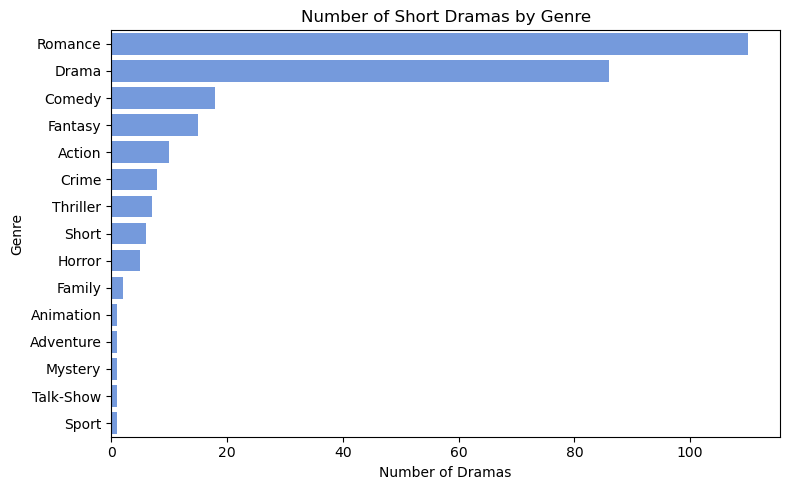

In [ ]:
# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    y=genre_counts.index,
    x=genre_counts.values,
    color="cornflowerblue"
)
plt.title("Number of Short Dramas by Genre")
plt.xlabel("Number of Dramas")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()